# Example 5: Machinery Fuel Consumption and Emissions

## Overview

This notebook demonstrates:
1. Creating power sources with efficiency and SFC curves
2. Defining fuel blends using FuelByMassFraction
3. Modeling machinery systems with separate propulsion and auxiliary systems
4. Calculating fuel consumption at different loads  
5. Analyzing performance and voyage fuel requirements

## Import Libraries

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from ship_model_lib.machinery import (
    Curve,
    FuelByMassFraction,
    LoadInput,
    MachinerySubsystemSimple,
    MachinerySystem,
    Point,
    PowerLoad,
    PowerSourceWithEfficiency,
    PowerSourceWithSpecificFuelConsumption,
)
from ship_model_lib.ship_types import PropulsionType

## Part 1: Fuel Properties

### Fuel Blends

**FuelByMassFraction** represents blends of different fuel types:
- Each parameter is the mass fraction (0-1) of that fuel type
- All fractions must sum to 1.0
- Supported fuels: diesel, hfo, natural_gas, hydrogen, ammonia, lpg, marine_gas_oil, methanol

**Example blends:**
- 100% HFO: `FuelByMassFraction(hfo=1.0)`
- 70% HFO + 30% MGO: `FuelByMassFraction(hfo=0.7, marine_gas_oil=0.3)`

In [5]:
# Define marine fuels as blends
# 100% Heavy Fuel Oil (HFO)
fuel_hfo = FuelByMassFraction(hfo=1.0)

# 100% Marine Gas Oil (MGO)
fuel_mgo = FuelByMassFraction(marine_gas_oil=1.0)

# Fuel blend: 70% HFO + 30% MGO
fuel_blend = FuelByMassFraction(hfo=0.7, marine_gas_oil=0.3)

print("Fuel Options:")
print(f"  HFO (100%):      LHV = {fuel_hfo.lhv_mj_per_kg:.1f} MJ/kg")
print(f"  MGO (100%):      LHV = {fuel_mgo.lhv_mj_per_kg:.1f} MJ/kg")
print(f"  Blend (70/30):   LHV = {fuel_blend.lhv_mj_per_kg:.1f} MJ/kg")

Fuel Options:
  HFO (100%):      LHV = 40.8 MJ/kg
  MGO (100%):      LHV = 42.8 MJ/kg
  Blend (70/30):   LHV = 41.4 MJ/kg


## Part 2: Main Engine with Efficiency Curve

### Thermal Efficiency

Modern marine diesel engines typically achieve:
- Peak efficiency: 48-52% (two-stroke)
- Efficiency varies with load
- Optimal load typically 75-85% MCR

In [6]:
# Define efficiency curve (typical for modern marine diesel)
# x = normalized load (power/rated_power), y = efficiency
efficiency_curve = Curve(
    points=[
        Point(x=0.10, y=0.35),
        Point(x=0.25, y=0.42),
        Point(x=0.50, y=0.48),
        Point(x=0.75, y=0.50),
        Point(x=0.85, y=0.50),
        Point(x=1.00, y=0.49),
    ]
)

print("Main Engine Specifications:")
print("  Type:          Two-stroke diesel")
print("  Rated Power:   15,000 kW (MCR)")
print("  Fuel:          HFO")

print(f"\n{'Load %':>8} | {'Efficiency':>12} | {'SFC (g/kWh)':>14}")
print("-" * 40)
for point in efficiency_curve.points:
    load_pct = point.x * 100
    eff_pct = point.y * 100
    sfc = 3600 / (point.y * fuel_hfo.lhv_mj_per_kg)
    print(f"{load_pct:>7.0f}% | {eff_pct:>11.1f}% | {sfc:>13.1f}")

Main Engine Specifications:
  Type:          Two-stroke diesel
  Rated Power:   15,000 kW (MCR)
  Fuel:          HFO

  Load % |   Efficiency |    SFC (g/kWh)
----------------------------------------
     10% |        35.0% |         252.1
     25% |        42.0% |         210.1
     50% |        48.0% |         183.8
     75% |        50.0% |         176.5
     85% |        50.0% |         176.5
    100% |        49.0% |         180.1


In [7]:
# Create main engine with efficiency curve
main_engine = PowerSourceWithEfficiency(
    efficiency=efficiency_curve,
    rated_power_kw=15000,
    fuel=fuel_hfo,
)

print("✓ Main engine created successfully")
print(f"  Rated Power: {main_engine.rated_power_kw} kW")
print(f"  Fuel: HFO (LHV = {main_engine.fuel.lhv_mj_per_kg:.1f} MJ/kg)")

✓ Main engine created successfully
  Rated Power: 15000 kW
  Fuel: HFO (LHV = 40.8 MJ/kg)


## Part 3: Auxiliary Engine with SFC Curve

Auxiliary engines use **Specific Fuel Consumption (SFC)** curves:

$$\text{SFC} = \frac{\text{Fuel Rate (g/h)}}{\text{Power (kW)}}$$

Typical values: 180-220 g/kWh (four-stroke diesel generators)

In [8]:
# Define SFC curve for auxiliary diesel generator
# x = normalized load, y = SFC in g/kWh
sfc_curve = Curve(
    points=[
        Point(x=0.25, y=220),
        Point(x=0.50, y=195),
        Point(x=0.75, y=185),
        Point(x=1.00, y=190),
    ]
)

print("Auxiliary Generator Specifications:")
print("  Type:          Four-stroke diesel")
print("  Rated Power:   750 kW")
print("  Fuel:          MGO")

# Create auxiliary engine with SFC curve
aux_engine = PowerSourceWithSpecificFuelConsumption(
    specific_fuel_consumption=sfc_curve,
    rated_power_kw=750,
    fuel=fuel_mgo,
)

print("\n✓ Auxiliary engine created successfully")
print(f"  Rated Power: {aux_engine.rated_power_kw} kW")

Auxiliary Generator Specifications:
  Type:          Four-stroke diesel
  Rated Power:   750 kW
  Fuel:          MGO

✓ Auxiliary engine created successfully
  Rated Power: 750 kW


## Part 4: Complete Machinery System

The machinery system is built using:
- **MachinerySubsystemSimple**: Connects power sources to loads
- **PowerLoad**: Models efficiency losses in power transmission
- **MachinerySystem**: Integrates mechanical and electric systems

In [9]:
# Create mechanical propulsion system
mechanical_system = MachinerySubsystemSimple(
    power_source=main_engine,
    propulsion_load=PowerLoad(efficiency=0.98),  # Shaft line efficiency
)

# Create electric system for auxiliary loads
electric_system = MachinerySubsystemSimple(
    power_source=aux_engine,
    auxiliary_load=PowerLoad(efficiency=0.95),  # Generator/distribution efficiency
)

# Create complete machinery system
machinery_system = MachinerySystem(
    propulsion_type=PropulsionType.MECHANICAL,
    mechanical_system=mechanical_system,
    electric_system=electric_system,
)

print("Machinery Configuration:")
print(f"  Propulsion Type:  Mechanical")
print(f"  Main Engine:      {main_engine.rated_power_kw} kW (propulsion)")
print(f"  Aux Engine:       {aux_engine.rated_power_kw} kW (auxiliaries)")

Machinery Configuration:
  Propulsion Type:  Mechanical
  Main Engine:      15000 kW (propulsion)
  Aux Engine:       750 kW (auxiliaries)


## Part 5: Fuel Consumption at Different Loads

Calculate fuel consumption using **LoadInput** to specify propulsion and auxiliary loads separately.

In [10]:
propulsion_powers = np.array([3000, 6000, 9000, 12000, 15000])  # kW
auxiliary_power = 400  # kW constant auxiliary load

print(f"{'Prop (kW)':>10} | {'Aux (kW)':>9} | {'Load %':>8} | {'Fuel (kg/h)':>12} | {'SFC (g/kWh)':>12}")
print("-" * 70)

results_data = []
for prop_power in propulsion_powers:
    # Create load inputs
    mechanical_load = LoadInput(propulsion_load_kw=prop_power)
    electric_load = LoadInput(auxiliary_load_kw=auxiliary_power)
    
    # Get machinery result
    result = machinery_system.get_machinery_result(
        mechanical_load=mechanical_load,
        electric_load=electric_load,
    )
    
    # Extract fuel consumption
    total_fuel_kg_h = result.total.fuel_consumption.total_fuel_consumption
    total_power = prop_power + auxiliary_power
    load_percent = (prop_power / main_engine.rated_power_kw) * 100
    sfc = (total_fuel_kg_h / total_power) * 1000 if total_power > 0 else 0
    
    results_data.append(total_fuel_kg_h)
    
    print(f"{prop_power:>10.0f} | {auxiliary_power:>9.0f} | {load_percent:>7.0f}% | {total_fuel_kg_h:>12.1f} | {sfc:>12.1f}")

 Prop (kW) |  Aux (kW) |   Load % |  Fuel (kg/h) |  SFC (g/kWh)
----------------------------------------------------------------------
      3000 |       400 |      20% |        752.5 |        221.3
      6000 |       400 |      40% |       1244.3 |        194.4
      9000 |       400 |      60% |       1725.0 |        183.5
     12000 |       400 |      80% |       2239.1 |        180.6
     15000 |       400 |     100% |       2850.5 |        185.1


## Part 6: Cruise Condition and Voyage Analysis

Analyze performance at cruise (75% MCR) and calculate daily/voyage fuel consumption.

In [11]:
# Cruise condition: 75% MCR
prop_power_cruise = 11250  # kW (75% of 15000)
mechanical_load_cruise = LoadInput(propulsion_load_kw=prop_power_cruise)
electric_load_cruise = LoadInput(auxiliary_load_kw=auxiliary_power)

result_cruise = machinery_system.get_machinery_result(
    mechanical_load=mechanical_load_cruise,
    electric_load=electric_load_cruise,
)

fuel_rate_cruise_kg_h = result_cruise.total.fuel_consumption.total_fuel_consumption

print(f"Cruise Condition (75% MCR):")
print(f"  Propulsion Power: {prop_power_cruise} kW")
print(f"  Auxiliary Power:  {auxiliary_power} kW") 
print(f"  Total Power:      {prop_power_cruise + auxiliary_power} kW")
print(f"  Fuel Rate:        {fuel_rate_cruise_kg_h:.1f} kg/h")

# Calculate daily consumption
hours_per_day = 24
daily_fuel_kg = fuel_rate_cruise_kg_h * hours_per_day
daily_fuel_tonnes = daily_fuel_kg / 1000

print(f"\nDaily Consumption at Cruise:")
print(f"  Fuel:  {daily_fuel_kg:.0f} kg/day ({daily_fuel_tonnes:.1f} tonnes/day)")

# Calculate voyage consumption
voyage_days = 10
voyage_fuel_tonnes = daily_fuel_tonnes * voyage_days

print(f"\n10-Day Voyage at Cruise:")
print(f"  Total Fuel:  {voyage_fuel_tonnes:.1f} tonnes")

Cruise Condition (75% MCR):
  Propulsion Power: 11250 kW
  Auxiliary Power:  400 kW
  Total Power:      11650 kW
  Fuel Rate:        2105.1 kg/h

Daily Consumption at Cruise:
  Fuel:  50522 kg/day (50.5 tonnes/day)

10-Day Voyage at Cruise:
  Total Fuel:  505.2 tonnes


## Part 7: Comprehensive Visualization

→ Saved 'example_05_machinery_fuel_emissions.png'


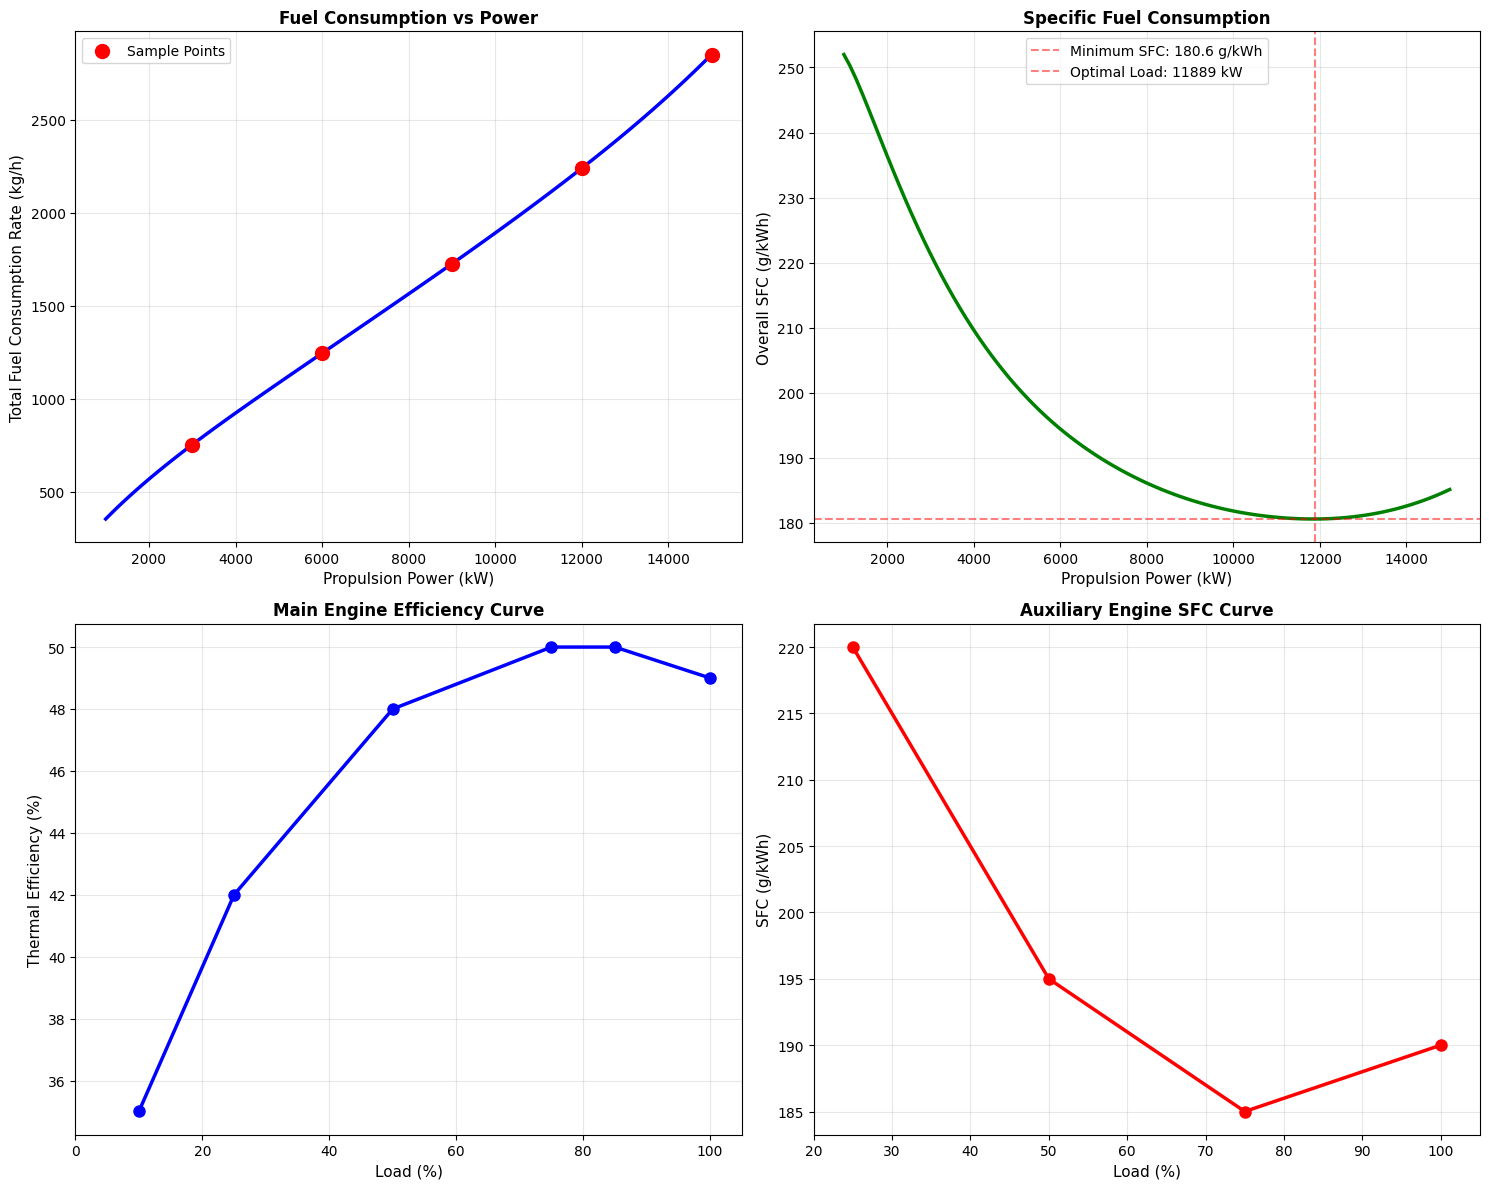

In [12]:
# Generate detailed curves
power_range = np.linspace(1000, 15000, 100)
fuel_rates_detailed = []
sfcs_detailed = []

for p in power_range:
    mech_load = LoadInput(propulsion_load_kw=p)
    elec_load = LoadInput(auxiliary_load_kw=auxiliary_power)
    res = machinery_system.get_machinery_result(
        mechanical_load=mech_load, electric_load=elec_load
    )
    fuel_rate = res.total.fuel_consumption.total_fuel_consumption
    fuel_rates_detailed.append(fuel_rate)
    total_pwr = p + auxiliary_power
    sfcs_detailed.append((fuel_rate / total_pwr) * 1000 if total_pwr > 0 else 0)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Fuel Consumption Rate
ax1.plot(power_range, fuel_rates_detailed, 'b-', linewidth=2.5)
ax1.scatter(propulsion_powers, results_data, color='red', s=100, zorder=5, label='Sample Points')
ax1.set_xlabel('Propulsion Power (kW)', fontsize=11)
ax1.set_ylabel('Total Fuel Consumption Rate (kg/h)', fontsize=11)
ax1.set_title('Fuel Consumption vs Power', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# Plot 2: Specific Fuel Consumption
ax2.plot(power_range, sfcs_detailed, 'g-', linewidth=2.5)
min_sfc = min(sfcs_detailed)
optimal_power = power_range[np.argmin(sfcs_detailed)]
ax2.axhline(y=min_sfc, color='r', linestyle='--', alpha=0.5, label=f'Minimum SFC: {min_sfc:.1f} g/kWh')
ax2.axvline(x=optimal_power, color='r', linestyle='--', alpha=0.5, label=f'Optimal Load: {optimal_power:.0f} kW')
ax2.set_xlabel('Propulsion Power (kW)', fontsize=11)
ax2.set_ylabel('Overall SFC (g/kWh)', fontsize=11)
ax2.set_title('Specific Fuel Consumption', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

# Plot 3: Main Engine Efficiency Curve
load_range = efficiency_curve.to_x_array() * 100
eff_range = efficiency_curve.to_y_array() * 100
ax3.plot(load_range, eff_range, 'b-o', linewidth=2.5, markersize=8)
ax3.set_xlabel('Load (%)', fontsize=11)
ax3.set_ylabel('Thermal Efficiency (%)', fontsize=11)
ax3.set_title('Main Engine Efficiency Curve', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_xlim([0, 105])

# Plot 4: Auxiliary Engine SFC Curve
load_range_aux = sfc_curve.to_x_array() * 100
sfc_range_aux = sfc_curve.to_y_array()
ax4.plot(load_range_aux, sfc_range_aux, 'r-o', linewidth=2.5, markersize=8)
ax4.set_xlabel('Load (%)', fontsize=11)
ax4.set_ylabel('SFC (g/kWh)', fontsize=11)
ax4.set_title('Auxiliary Engine SFC Curve', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.set_xlim([20, 105])

plt.tight_layout()
plt.savefig('example_05_machinery_fuel_emissions.png', dpi=150, bbox_inches='tight')
print("→ Saved 'example_05_machinery_fuel_emissions.png'")
plt.show()

## Summary

In [13]:
print("Machinery Performance:")
print(f"  Optimal SFC:          {min_sfc:.1f} g/kWh at {optimal_power:.0f} kW")
print(f"  Main Engine Peak Eff: {max(efficiency_curve.to_y_array())*100:.1f}%")
print(f"\nCruise Operation (75% MCR):")
print(f"  Propulsion Power:     {prop_power_cruise} kW")
print(f"  Fuel Rate:            {fuel_rate_cruise_kg_h:.1f} kg/h")
print(f"  Daily Fuel:           {daily_fuel_tonnes:.1f} tonnes")
print(f"  10-day Voyage Fuel:   {voyage_fuel_tonnes:.1f} tonnes")

Machinery Performance:
  Optimal SFC:          180.6 g/kWh at 11889 kW
  Main Engine Peak Eff: 50.0%

Cruise Operation (75% MCR):
  Propulsion Power:     11250 kW
  Fuel Rate:            2105.1 kg/h
  Daily Fuel:           50.5 tonnes
  10-day Voyage Fuel:   505.2 tonnes


## Key Takeaways

1. **Fuel Blends:**
   - FuelByMassFraction models blends of different fuel types (HFO, MGO, LNG, etc.)
   - Mass fractions must sum to 1.0
   - LHV calculated automatically based on blend composition

2. **Engine Efficiency:**
   - Peak efficiency at 75-85% MCR
   - Significant efficiency drop at low loads (<25%)
   - Two-stroke engines more efficient than four-stroke

3. **Machinery System:**
   - Mechanical propulsion system for main engine
   - Electric system for auxiliary loads
   - LoadInput separates propulsion and auxiliary power demands

4. **Fuel Consumption:**
   - SFC minimum at optimal load point
   - Daily consumption heavily influenced by operating profile
   - Total system SFC includes both propulsion and auxiliary loads